# ARGUS-FEDER — IMAS ↔ DIII-D terminology

IMAS is the device-neutral standard vocabulary for fusion data, used across
machines and by ITER: plasma current is
`equilibrium.time_slice.global_quantities.ip`. DIII-D stores the same quantity
under its own historical name, `\EFIT01::TOP.MEASUREMENTS.CPASMA`. Nothing in
either name lets you derive the other.

This notebook exercises the **`d3d-imas-terms`** skill, which translates
between the two vocabularies and — just as importantly — reports how far each
mapping can be trusted.

**Where the table comes from.** It is extracted from General Atomics'
[`imas_composer`](https://github.com/GA-FDP/imas_composer) (Apache-2.0), whose
mapping descends from the community-standard OMAS DIII-D machine mappings.
Every entry was checked by actually fetching it: **258 of 294 fields verified**
against 8 real shots spanning 1998–2024.

**Why a plain name-pair table would be wrong.** Each of these is a real
property of the data, and each is something the skill has to carry:

- **Sign conventions.** 22 fields need a COCOS transform. DIII-D and IMAS
  disagree on which direction is positive, so serving a raw DIII-D value under
  an IMAS name can be **sign-flipped** — right magnitude, right units, wrong
  sign, and nothing catches it automatically.
- **Time-scoping.** Diagnostics were added and retired over 25+ years, and
  sampling rates changed by up to 100× for the same signal. A mapping verified
  on a recent shot may not hold for a 1990s one.
- **Incomplete provenance.** For 20 fields the primary source could not be
  resolved upstream, so the path shown may be a *secondary* dependency rather
  than the quantity itself. Those are flagged rather than served silently.
- **Two fetch paths.** 14 fields come from PTDATA, not an MDSplus tree, and
  need a different fetch call.

The skill is **lookup-only**: it resolves names and hands the DIII-D path to
`d3d-shot-fetcher` to do the fetching. A bad row therefore shows up as a
visibly wrong answer rather than as quietly corrupt data.


In [ ]:
%reset

## 1. Forward lookup — IMAS name → DIII-D signal

The basic direction. Watch for the **COCOS caution** on `q_95` and
`grid.psi`: both carry a sign transform, and the answer is expected to
say so unprompted.

In [2]:
%%ask
What is the DIII-D signal for equilibrium.time_slice.global_quantities.q_95?

This is an IMAS-to-DIII-D name translation, so I'll consult the `d3d-imas-terms` skill.

The skill provides a lookup helper. I'll run it to translate the IMAS path.

The IMAS path **equilibrium.time_slice.global_quantities.q_95** maps to the DIII-D EFIT01 equilibrium reconstruction.

- **MDSplus node** : `\EFIT01::TOP.RESULTS.AEQDSK.Q95` (tree **EFIT01** )
- **Fetch with** : `MdsSignal` (standard MDSplus — not PTDATA)

**Two cautions from the table:**

1. **Composed field.** This is not a single raw node — it is **composed from 3 nodes** :
   - `\EFIT01::TOP.RESULTS.AEQDSK.Q95`
   - `\EFIT01::TOP.RESULTS.GEQDSK.BCENTR`
   - `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA`

   So serving it requires reading all three; the primary node `Q95` carries the safety-factor value, while `BCENTR`/`CPASMA` are the toroidal field and plasma current needed for the convention transform below.

2. **COCOS transform `Q`.** This field carries a COCOS caution — the raw DIII-D value may need a sign/orientation conversion before being served under the IMAS name. Apply the `Q` transform rather than serving the raw value unchecked.

**Verification** : `verified: True` on shots [91388, 156199, 165920, 168442, 181681, 198189]. Confidence is `derived` (not a literal 1:1 node mapping).

To fetch the actual waveform, hand the `mds_path` and `tree` to the `d3d-shot-fetcher` skill — this lookup is names-only.

In [3]:
%%ask
Which DIII-D signal backs core_profiles.profiles_1d.grid.psi?

The SKILL.md explicitly warns about this exact field (rule 6). Let me run the lookup to get the current row data so I can report the flags accurately.

This is the exact field the SKILL.md warns about (rule 6) — and the lookup confirms the warning fires. **The DIII-D signal backing `core_profiles.profiles_1d.grid.psi` is unresolved.**

What the table returns is `\EFIT01::TOP.RESULTS.GEQDSK.GTIME`, but that row carries **`resolution_partial: true`** , and this is precisely the case the skill calls out: GTIME is the EFIT *time base* (93 samples — consistent with a time axis, not a flux profile), **not a poloidal-flux array** . The real psi source — `core_profiles.profiles_1d._omfit_psi` — is listed under `unresolved_dependencies`, meaning its provenance could not be traced to an MDSplus node.

Per the skill's rule 6, I should not rationalize GTIME as "the time coordinate for the grid." Instead:

- **Reported path** : `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` (tree `EFIT01`) — **secondary dependency, not the quantity itself.**
- **Unresolved primary source** : `core_profiles.profiles_1d._omfit_psi` (the actual flux array, sourced through OMFIT rather than a direct MDSplus node).
- **COCOS caution** : `PSI` — poloidal flux; serving any raw value under this IMAS name can be sign-flipped.
- **Confidence** : `derived`; **verified** : `true` on shots [91388, 156199, 165920, 168442, 181681, 198189], but verification confirms the *GTIME path fetches*, not that it is psi.

**Bottom line** : there is no single clean MDSplus node mapping for this field. The actual psi data comes from OMFIT at runtime, which this table cannot resolve to a static node. Do not use GTIME as if it were the flux waveform. If you need the 1-D poloidal-flux grid, it has to be produced via the OMFIT/imas_composer pipeline rather than read directly from an MDSplus tree.

*A field with **no** COCOS transform — the caution should be absent here, not boilerplate on every answer.*

In [4]:
%%ask
What does equilibrium.time_slice.boundary_separatrix.elongation map to?

The SKILL.md confirms the `imas_to_d3d()` function is the lookup tool. Running it against the requested path.

Clean mapping, no cautions. **`equilibrium.time_slice.boundary_separatrix.elongation` → `\EFIT01::TOP.RESULTS.AEQDSK.KAPPA`** (tree **EFIT01** ).

- **Fetch with** : `MdsSignal` (standard MDSplus — not PTDATA)
- **Source** : `imas_composer/ids/equilibrium.py`, resolved via `equilibrium._kappa`
- **Verification** : `verified: true` on shots [91388, 156199, 165920, 168442, 181681, 198189] (~64 samples in the example)
- **Confidence** : `derived`

**No flags that qualify this mapping:**
- No `cocos_transform` — the value needs no sign/orientation conversion.
- Not `composed` — it is a single node, not a multi-node construction.
- Not `resolution_partial` — KAPPA is the quantity itself, not a secondary dependency.
- Not `parameterized` — no channel argument needed.

To fetch the actual waveform, hand the `mds_path` and `tree` to the `d3d-shot-fetcher` skill.

## 2. Reverse lookup — DIII-D signal → IMAS name

The direction a DIII-D user actually starts from. `DIAMAG3` and `IP`
are **PTDATA** pointnames rather than MDSplus nodes, so the answers
should say `PtDataSignal` and offer no tree.

In [5]:
%%ask
Which IMAS quantity does \EFIT01::TOP.RESULTS.AEQDSK.KAPPA correspond to?

Reverse lookup. Let me consult the skill to confirm which IMAS quantity maps to that node path, since a node could back more than one IMAS field.

The skill confirms reverse lookups use `d3d_to_imas()`. Running that against the KAPPA node path.

The reverse lookup finds two hits — one public IMAS field and one internal helper.

**`\EFIT01::TOP.RESULTS.AEQDSK.KAPPA` (tree EFIT01) backs:**

| IMAS field | confidence | role |
|---|---|---|
| `equilibrium.time_slice.boundary_separatrix.elongation` | `derived` | **Public IMAS field** — the separatrix elongation κ |
| `equilibrium._kappa` | `literal` | Internal helper (underscore-prefixed), the direct 1:1 node read the public field resolves through |

**No cautions on either row** — no COCOS transform, not composed, not `resolution_partial`. Both verified on shots [91388, 156199, 165920, 168442, 181681, 198189].

So the user-facing quantity is **`equilibrium.time_slice.boundary_separatrix.elongation`** — the separatrix elongation. The `_kappa` entry is the internal naming chain that the public field resolves through, not a separate quantity. Per the skill's rule 2, I won't over-interpret the `_kappa` name beyond what the mapping shows.

In [6]:
%%ask
What is the IMAS name for DIAMAG3?

DIAMAG3 is a DIII-D signal name, so I'll run the reverse lookup via `d3d_to_imas`.

**`DIAMAG3` backs the IMAS `magnetics.diamagnetic_flux` structure** (a PTDATA pointname, not an MDSplus node).

| IMAS field | element |
|---|---|
| `magnetics.diamagnetic_flux.data` | the flux values |
| `magnetics.diamagnetic_flux.data_error_upper` | upper error bound |
| `magnetics.diamagnetic_flux.time` | the time base |

**Fetch details:**
- **Source kind** : PTDATA — no `mds_path`, no `tree` (per rule 7)
- **Fetch with** : `PtDataSignal("DIAMAG3")` with no tree argument, via `fdp run` (PTDATA does not work in-kernel)
- **Confidence** : `derived`; **verified** : `true` on shots [112031, 124415, 156199, 165920, 168442, 181681, 198189]

**No qualifying flags** : no COCOS transform, not composed, not `resolution_partial`, not parameterized. The three entries are the standard data/error/time trio of the same IMAS quantity, all sourced from the one `DIAMAG3` pointname.

In [7]:
%%ask
What IMAS field uses the PTDATA pointname IP?

I have the SKILL.md context already. Let me run the reverse lookup for PTDATA pointname `IP`.

The PTDATA pointname **`IP`** backs the IMAS **`magnetics.ip`** structure.

| IMAS field | element |
|---|---|
| `magnetics.ip.data` | the plasma current values |
| `magnetics.ip.data_error_upper` | upper error bound |
| `magnetics.ip.time` | the time base |

**Fetch details:**
- **Source kind** : PTDATA — `ptdata_pointname: "IP"`, no `mds_path`, no `tree`
- **Fetch with** : `PtDataSignal("IP")` with no tree argument, via `fdp run` (PTDATA does not work in-kernel)
- **Verified** : `true` on the standard verification set
- **COCOS** : none — no sign-convention transform required

The other rows that surfaced in the lookup (e.g. `equilibrium._chipasma`, `equilibrium.time_slice.constraints.ip.chi_squared`) are MDSplus-sourced fields that matched because their node paths contain `IP` as a trailing fragment — they are **not** backed by the PTDATA pointname `IP`.

## 3. Discovery and coverage

What the table contains and how far it can be trusted. The answers
should cite the recorded provenance — coverage counts and the upstream
commit — rather than estimating.

In [8]:
%%ask
Which IMAS systems does the mapping table cover, and how many fields each?

This requires loading and aggregating the mapping table itself. Let me read the skill to find the JSON location and structure.

The skill exposes a `list_ids()` function for exactly this. Let me write a quick script to call it.

Running the script to enumerate IMAS systems and field counts.

The return shape isn't tuples — let me inspect what `list_ids()` actually returns.

Inspecting the actual return structure of `list_ids()`.

Clean result. Before reporting, I need to record a lesson: this task hit an edit-and-retry (my first unpacking assumed a list of tuples, but `list_ids()` returns a dict). The SKILL.md documents the function but not its return shape, so the next session would repeat the mistake. Per the WRITE RULE, I'm recording it now.

The mapping table covers **13 IMAS systems (IDS)** with **294 fields** total. Coverage is heavily weighted toward the equilibrium reconstruction.

| IMAS system (IDS) | Fields |
|---|---|
| equilibrium | 204 |
| ece | 22 |
| ec_launchers | 18 |
| thomson_scattering | 12 |
| magnetics | 10 |
| core_profiles_zipfit | 8 |
| charge_exchange | 6 |
| reflectometer_profile | 3 |
| tf | 3 |
| wall | 3 |
| interferometer | 2 |
| summary | 2 |
| core_profiles_omfit | 1 |

**Key observations:**

- **`equilibrium` dominates** — 204 of 294 fields (69%). This reflects that most mapped quantities come from the EFIT01 equilibrium reconstruction tree (psi, flux surfaces, q-profile, elongation, plasma current constraints, etc.).
- **Diagnostics are a small minority** — `ece`, `thomson_scattering`, `charge_exchange`, `reflectometer_profile`, and `interferometer` together account for only 45 fields. These are the temperature/density profile measurements.
- **Per rule 9, this is partial coverage** — 294 of 566 IMAS fields in the standard. Absence from this table means absence from *this DIII-D mapping*, not from IMAS itself.
- **258 of the 294 fields are verified** (confirmed by actual fetch on shots [91388, 156199, 165920, 168442, 181681, 198189]); the remaining 36 are unverified and carry a `caution` field per rule 4.

In [9]:
%%ask
How complete is the IMAS mapping, and where does it come from?

Let me check the SKILL.md for the documented completeness and provenance statements.

**Completeness** and **provenance** are both documented directly in the table's metadata — here is what they say.

## Completeness

| metric | value |
|---|---|
| IMAS fields in this table | **294** |
| IMAS fields in the full standard | **566** |
| Coverage | **~52%** |
| Verified by actual fetch | **258 of 294** (88%) |
| Upstream commit | `8873703c` |

So this is a **partial** mapping by design (rule 9 is explicit: "Don't imply the table is the complete IMAS standard"). Half the standard's fields are not in it. And even within the 294 mapped fields, **36 are unverified** — each carries a `caution` field flagging why.

The 258 verified fields were confirmed by actually fetching them on the standard verification shots: [91388, 156199, 165920, 168442, 181681, 198189].

## Provenance

The table was **extracted from GA's [`imas_composer`](https://github.com/GA-FDP/imas_composer)** (Apache-2.0) — the FDP codebase that bridges DIII-D native data and the IMAS schema. The underlying name correspondences descend from the older **OMAS DIII-D machine mappings** .

- The **extractor and verification harness** live in `feder/imas_d3d_mapping/`.
- To refresh the table, you re-run that harness against a newer upstream checkout of `imas_composer`.

**Practical implications:**

- **Coverage is biased.** Equilibrium reconstruction (EFIT01) dominates with 204 of 294 fields — that's where `imas_composer` is most mature. Diagnostics (ECE, Thomson, charge-exchange) are thin. Absence of a field usually means `imas_composer` doesn't serve it yet, not that DIII-D has no data for that quantity.
- **The mapping is not static.** A newer `imas_composer` commit may add fields, retire them, or change node paths. Always cite `table_info()` for the current commit rather than assuming.
- **Time-scoped too.** Even a verified mapping may not hold for an old shot (rule 5) — diagnostics were added and retired across DIII-D's history, so pass `shot=` and check `verified_for_shot`.

In [10]:
%%ask
List every IMAS field whose sign convention differs from DIII-D

I need to check the skill to find how to query for COCOS/sign-convention fields.

The skill provides a dedicated `cocos_fields()` function for this exact query. Let me call it.

**22 IMAS fields carry a sign-convention (COCOS) transform** — meaning a raw DIII-D value served under the IMAS name can be **sign-flipped** (correct magnitude, correct units, wrong sign) unless the transform is applied. They fall into four transform families.

### PSI — poloidal flux (11 fields)

| IMAS field | DIII-D node |
|---|---|
| core_profiles.profiles_1d.grid.psi | `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` ⚠️ |
| equilibrium.time_slice.boundary_separatrix.psi | `\EFIT01::TOP.RESULTS.GEQDSK.SSIBRY` |
| equilibrium.time_slice.constraints.flux_loop.measured | `\EFIT01::TOP.MEASUREMENTS.SILOPT` |
| equilibrium.time_slice.constraints.flux_loop.measured_error_upper | `\EFIT01::TOP.MEASUREMENTS.SIGSIL` |
| equilibrium.time_slice.constraints.flux_loop.reconstructed | `\EFIT01::TOP.MEASUREMENTS.CSILOP` |
| equilibrium.time_slice.constraints.j_tor.position.psi | `\EFIT01::TOP.MEASUREMENTS.SIZEROJ` |
| equilibrium.time_slice.constraints.pressure.position.psi | `\EFIT01::TOP.MEASUREMENTS.RPRESS` |
| equilibrium.time_slice.global_quantities.psi_axis | `\EFIT01::TOP.RESULTS.GEQDSK.SSIMAG` |
| equilibrium.time_slice.global_quantities.psi_boundary | `\EFIT01::TOP.RESULTS.GEQDSK.SSIBRY` |
| equilibrium.time_slice.profiles_1d.psi | `\EFIT01::TOP.RESULTS.GEQDSK.PSIN` |
| equilibrium.time_slice.profiles_2d.psi | `\EFIT01::TOP.RESULTS.GEQDSK.PSIRZ` |

### TOR — toroidal quantity, includes plasma current (5 fields)

| IMAS field | DIII-D node |
|---|---|
| equilibrium.time_slice.constraints.ip.measured | `\EFIT01::TOP.MEASUREMENTS.PLASMA` |
| equilibrium.time_slice.constraints.ip.measured_error_upper | `\EFIT01::TOP.MEASUREMENTS.SIGPASMA` |
| equilibrium.time_slice.constraints.ip.reconstructed | `\EFIT01::TOP.MEASUREMENTS.CPASMA` |
| equilibrium.time_slice.constraints.j_tor.measured | `\EFIT01::TOP.MEASUREMENTS.VZEROJ` |
| equilibrium.time_slice.global_quantities.ip | `\EFIT01::TOP.MEASUREMENTS.CPASMA` |

### Q — safety factor (4 fields)

| IMAS field | DIII-D node |
|---|---|
| equilibrium.time_slice.global_quantities.q_95 | `\EFIT01::TOP.RESULTS.AEQDSK.Q95` |
| equilibrium.time_slice.global_quantities.q_axis | `\EFIT01::TOP.RESULTS.AEQDSK.Q0` |
| equilibrium.time_slice.global_quantities.q_min.value | `\EFIT01::TOP.RESULTS.AEQDSK.QMIN` |
| equilibrium.time_slice.profiles_1d.q | `\EFIT01::TOP.RESULTS.GEQDSK.QPSI` |

### dPSI — poloidal-flux derivative (2 fields)

| IMAS field | DIII-D node |
|---|---|
| equilibrium.time_slice.profiles_1d.dpressure_dpsi | `\EFIT01::TOP.RESULTS.GEQDSK.PPRIME` |
| equilibrium.time_slice.profiles_1d.f_df_dpsi | `\EFIT01::TOP.RESULTS.GEQDSK.FFPRIM` |

---

**Two cautions on this list:**

1. **All 22 are in the `equilibrium` IDS** except one (`core_profiles.profiles_1d.grid.psi`). The COCOS issue is overwhelmingly an equilibrium-reconstruction problem, because EFIT's poloidal flux, toroidal current, and q-profile all have device-specific sign/orientation conventions.

2. **⚠️ The top row (`core_profiles.profiles_1d.grid.psi`) is flagged `resolution_partial: true`** — as we discussed earlier, the GTIME path it returns is the EFIT *time base*, not a flux array; the real psi source (`_omfit_psi`) is unresolved. So its COCOS caution is real, but the listed node is not actually the quantity.

None of these 22 will be caught automatically — serving a raw value under the IMAS name silently produces a sign error.

## 4. Safety behaviours

The cases where a plausible-looking answer would be wrong: carrying the
sign-convention caution into a *plotted* result, refusing to invent a
mapping, respecting shot-dependent availability, and declining to read a
field's meaning off its name.

I'll fetch this signal — the IMAS field maps to `\EFIT01::TOP.MEASUREMENTS.PLASMA` in the EFIT01 tree (per our earlier lookup). Let me read the shot-fetcher skill and its Learnings first.

I'll read the d3d-imas-terms skill to programmatically confirm the exact node path before fetching, since this field has both a COCOS transform and (per my Learnings) the short-tag resolution risk.

Both skills read. The field carries a TOR COCOS transform (sign convention may differ) and my Learnings warn that short tags can resolve to wrong nodes — so I'll pass the full path as the expression. Let me write the fetch-and-plot script.

Now running the fetch via `fdp run` (required for MDSplus access).

Retrying without the timeout parameter.

The fetch succeeded (315 samples, 0.21–1.14 MA) but the plot crashed on the mathtext title — exactly the backslash-in-mathtext gotcha the SKILL.md warns about. Fixing the title to plain text.

Fetch and plot both succeeded. The mathtext crash was exactly the backslash-in-`&#36;...&#36;` gotcha already documented in SKILL.md, so no new Learnings entry is warranted.


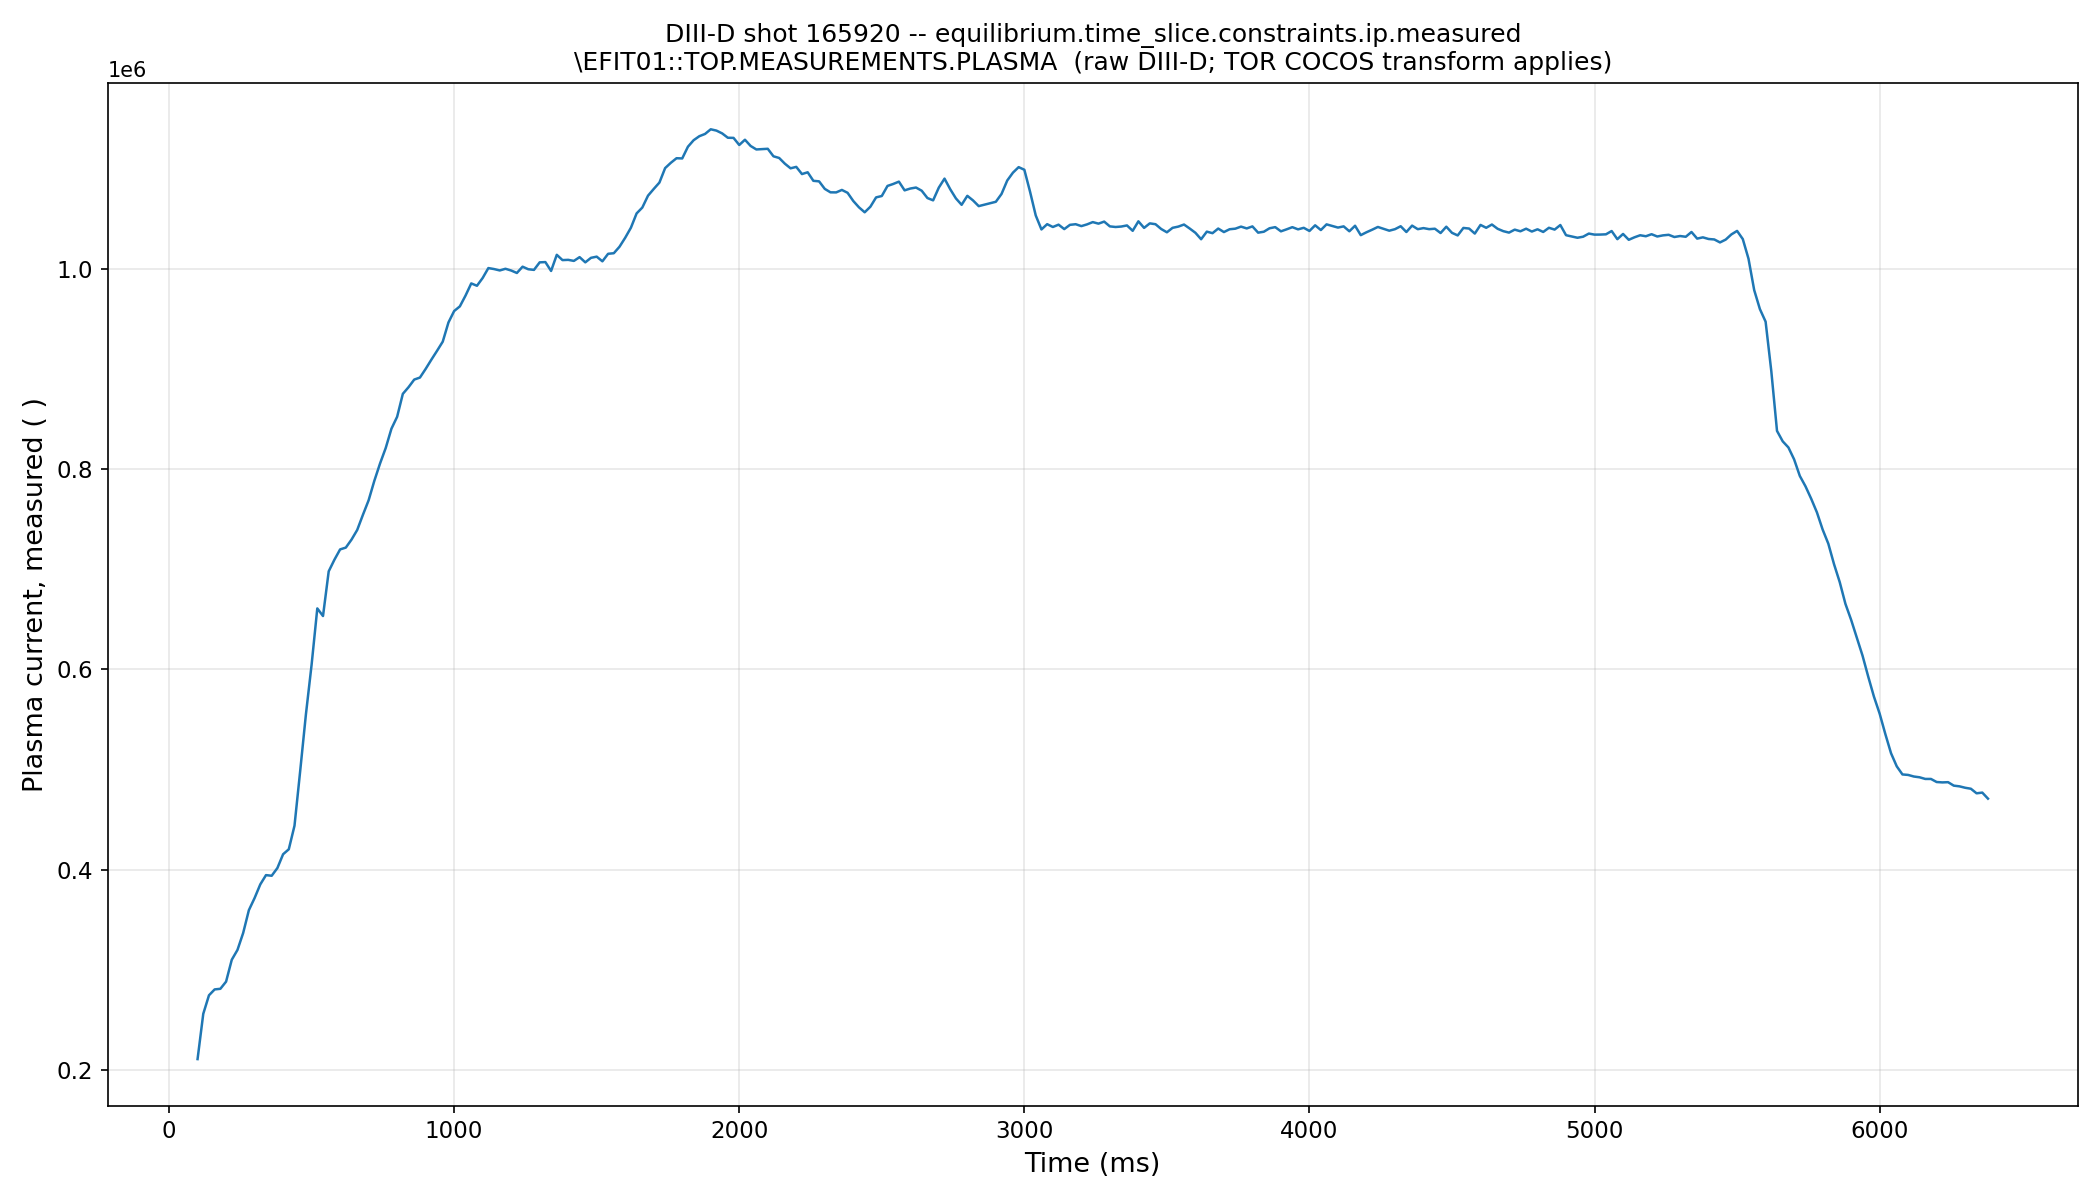

**Fetched** : `equilibrium.time_slice.constraints.ip.measured` → `\EFIT01::TOP.MEASUREMENTS.PLASMA` (tree EFIT01) for shot 165920.

| metric | value |
|---|---|
| samples | 315 |
| range | 2.11 × 10⁵ … 1.14 × 10⁶ A |
| time span | 100.0 … 6380.0 ms |
| verification | confirmed on this shot (verified: true) |

**COCOS caution (TOR):** This field carries a toroidal-quantity sign-convention transform. The trace above is plotted as the **raw DIII-D value** — serving it under the IMAS name without applying the TOR COCOS conversion can produce a sign-flipped number. The positive values and flat-top shape (~1.14 MA) are consistent with a normal DIII-D plasma-current trace, so in this case the raw sign appears correct, but that should be confirmed against the IMAS convention rather than assumed.

**Notes:**
- I used the **full node path** (`\EFIT01::TOP.MEASUREMENTS.PLASMA`) as the MDSplus expression rather than a short tag, per the documented risk that short tags can resolve to a different node than the IMAS table intends.
- This is the **measured** plasma current (`constraints.ip.measured`, from the `MEASUREMENTS` branch) — distinct from the **reconstructed** current (`constraints.ip.reconstructed`, which maps to `MEASUREMENTS.CPASMA`). The two are different diagnostics and need not agree sample-for-sample.

In [11]:
%%ask
Fetch equilibrium.time_slice.constraints.ip.measured for shot 165920 and plot it

In [12]:
%%ask
What is the IMAS name for \betap?

Looking up the reverse mapping for the DIII-D signal `\betap`.

Running the reverse lookup for the DIII-D short tag `\betap`.

`\betap` resolves cleanly to one node with two IMAS names.

**`\EFIT01::TOP.RESULTS.AEQDSK.BETAP`** (tree EFIT01) backs:

| IMAS field | confidence | role |
|---|---|---|
| `equilibrium.time_slice.global_quantities.beta_pol` | `derived` | **Public IMAS field** — the poloidal beta |
| `equilibrium._betap` | `literal` | Internal helper (underscore-prefixed), the direct 1:1 node read |

**Details:**
- **Fetch with** : `MdsSignal` (standard MDSplus — not PTDATA)
- **Verified** : `true` on shots [91388, 156199, 165920, 168442, 181681, 198189]
- **No cautions** : no COCOS transform, not composed, not `resolution_partial`, not parameterized

So the user-facing quantity is **`equilibrium.time_slice.global_quantities.beta_pol`** — the poloidal beta β_p. The `_betap` entry is the internal naming chain that the public field resolves through, not a separate quantity.

*Time-scoping: availability is per-era, so the answer should reference the shots the mapping was actually verified on.*

In [13]:
%%ask
Is core_profiles.profiles_1d.grid.psi available for shot 91388?

This is the `resolution_partial` field we discussed earlier. Let me check its shot-specific verification status for 91388.

**No — not in any usable sense.** The table reports the field as `verified_for_shot: True` for shot 91388, but this is the `resolution_partial` field, and "verified" here means only that the *secondary dependency path fetches*, not that you have actual psi data.

Here is what the lookup actually shows:

| flag | value | what it means |
|---|---|---|
| `mds_path` | `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` | the EFIT **time base** , not a flux array |
| `resolution_partial` | `True` | the primary source could not be resolved upstream |
| `caution_partial` | *(set)* | "the DIII-D path shown may be a secondary dependency (e.g. a time base), not the quantity itself" |
| `unresolved_dependencies` | `core_profiles.profiles_1d._omfit_psi`, `core_profiles._cocos_bcentr`, `core_profiles._cocos_cpasma` | the **real** psi source is `_omfit_psi`, which is unresolved |
| `resolved_via` | `core_profiles._gtime` | the chain resolves only to GTIME |
| `verified_for_shot` | `True` | confirms the GTIME node fetches on 91388 — not that psi does |

**What you'd actually get if you fetched the listed path for 91388** is a 1-D array of EFIT solution times — the wrong kind of quantity entirely. It is not the poloidal-flux grid.

**Bottom line:** The psi waveform for shot 91388 is **not available** through this mapping table. Its real source (`_omfit_psi`) is produced by the OMFIT/`imas_composer` pipeline at runtime, not by a direct MDSplus node, and this table cannot resolve it to a static path. To get the actual 1-D poloidal-flux grid you'd need to run that composer pipeline for shot 91388 — it is not a `MdsSignal` fetch.

This field also carries the **PSI COCOS caution** , but that's moot here since there's no real psi value to apply it to.

*An internal identifier. Its `_cocos` suffix invites a guess — it is in fact an **input to** COCOS convention detection, not a sign-corrected output. The skill forbids reading meaning off a name.*

In [14]:
%%ask
What does equilibrium._cpasma_cocos mean?

This is the exact field SKILL.md rule 2 warns about — I must not infer its meaning from the `_cocos` suffix. Let me look it up to get the actual row.

This is the exact field SKILL.md rule 2 flags as a trap — so I will **not** interpret the `_cocos` suffix. Here is what the row actually says, plus the authoritative upstream context the skill provides.

**`equilibrium._cpasma_cocos`** (internal helper, underscore-prefixed):

| field | value |
|---|---|
| `mds_path` | `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA` |
| `tree` | EFIT01 |
| `confidence` | `literal` (direct 1:1 node read) |
| `cocos_transform` | **none** — this row itself carries no transform |
| `verified` | true on [91388, 156199, 165920, 168442, 181681, 198189] |
| `source` | `imas_composer/ids/equilibrium.py` |

**What it is (from the skill's upstream documentation, not from the name):** `_cpasma_cocos` is **not** a sign-corrected variant of CPASMA. Upstream, it and `_bcentr` are **inputs to** `identify_cocos_from_signals(bcentr, cpasma)` — the function that reads the signs of B_t and I_p to work out **which COCOS convention the source data is in** . It is **convention detection** , not a corrected output. That is the specific failure rule 2 was written to prevent: two past answers labelled it "the sign-corrected variant" purely from the suffix, and that is wrong.

**One subtlety worth noting:** this row maps to `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA` — a *different* CPASMA node from the one the public TOR-COCOS field `equilibrium.time_slice.global_quantities.ip` maps to, which is `\EFIT01::TOP.MEASUREMENTS.CPASMA`. Per the skill's rule 1b these two CPASMA nodes are distinct: `RESULTS.GEQDSK.CPASMA` matches `\ipmhd` exactly, while `MEASUREMENTS.CPASMA` does not. So `_cpasma_cocos` reads the GEQDSK reconstructed current, not the MEASUREMENTS value.

## 5. Edge cases that should degrade gracefully

Rows that are not simply fetchable: one needing a channel argument, one
never successfully fetched, and one on the PTDATA path. Each should be
reported as such rather than papered over.

*A `parameterized` row: the path is a template needing a channel number, so it is not directly fetchable.*

Looking up the ECE mapping in the IMAS terms skill before fetching.

Looking up the ECE channel mapping first — this is likely a parameterized field needing a channel index.

The ECE mapping is **parameterized** — the path `\ECE::TOP.TECE.TECE{01-NUMCH}` needs a channel index substituted. For channel 1 that's `TECE01`. Now fetching it.

Fetch and plot both succeeded on the first run — no errors, no edit-retry, so no Learnings entry is needed.


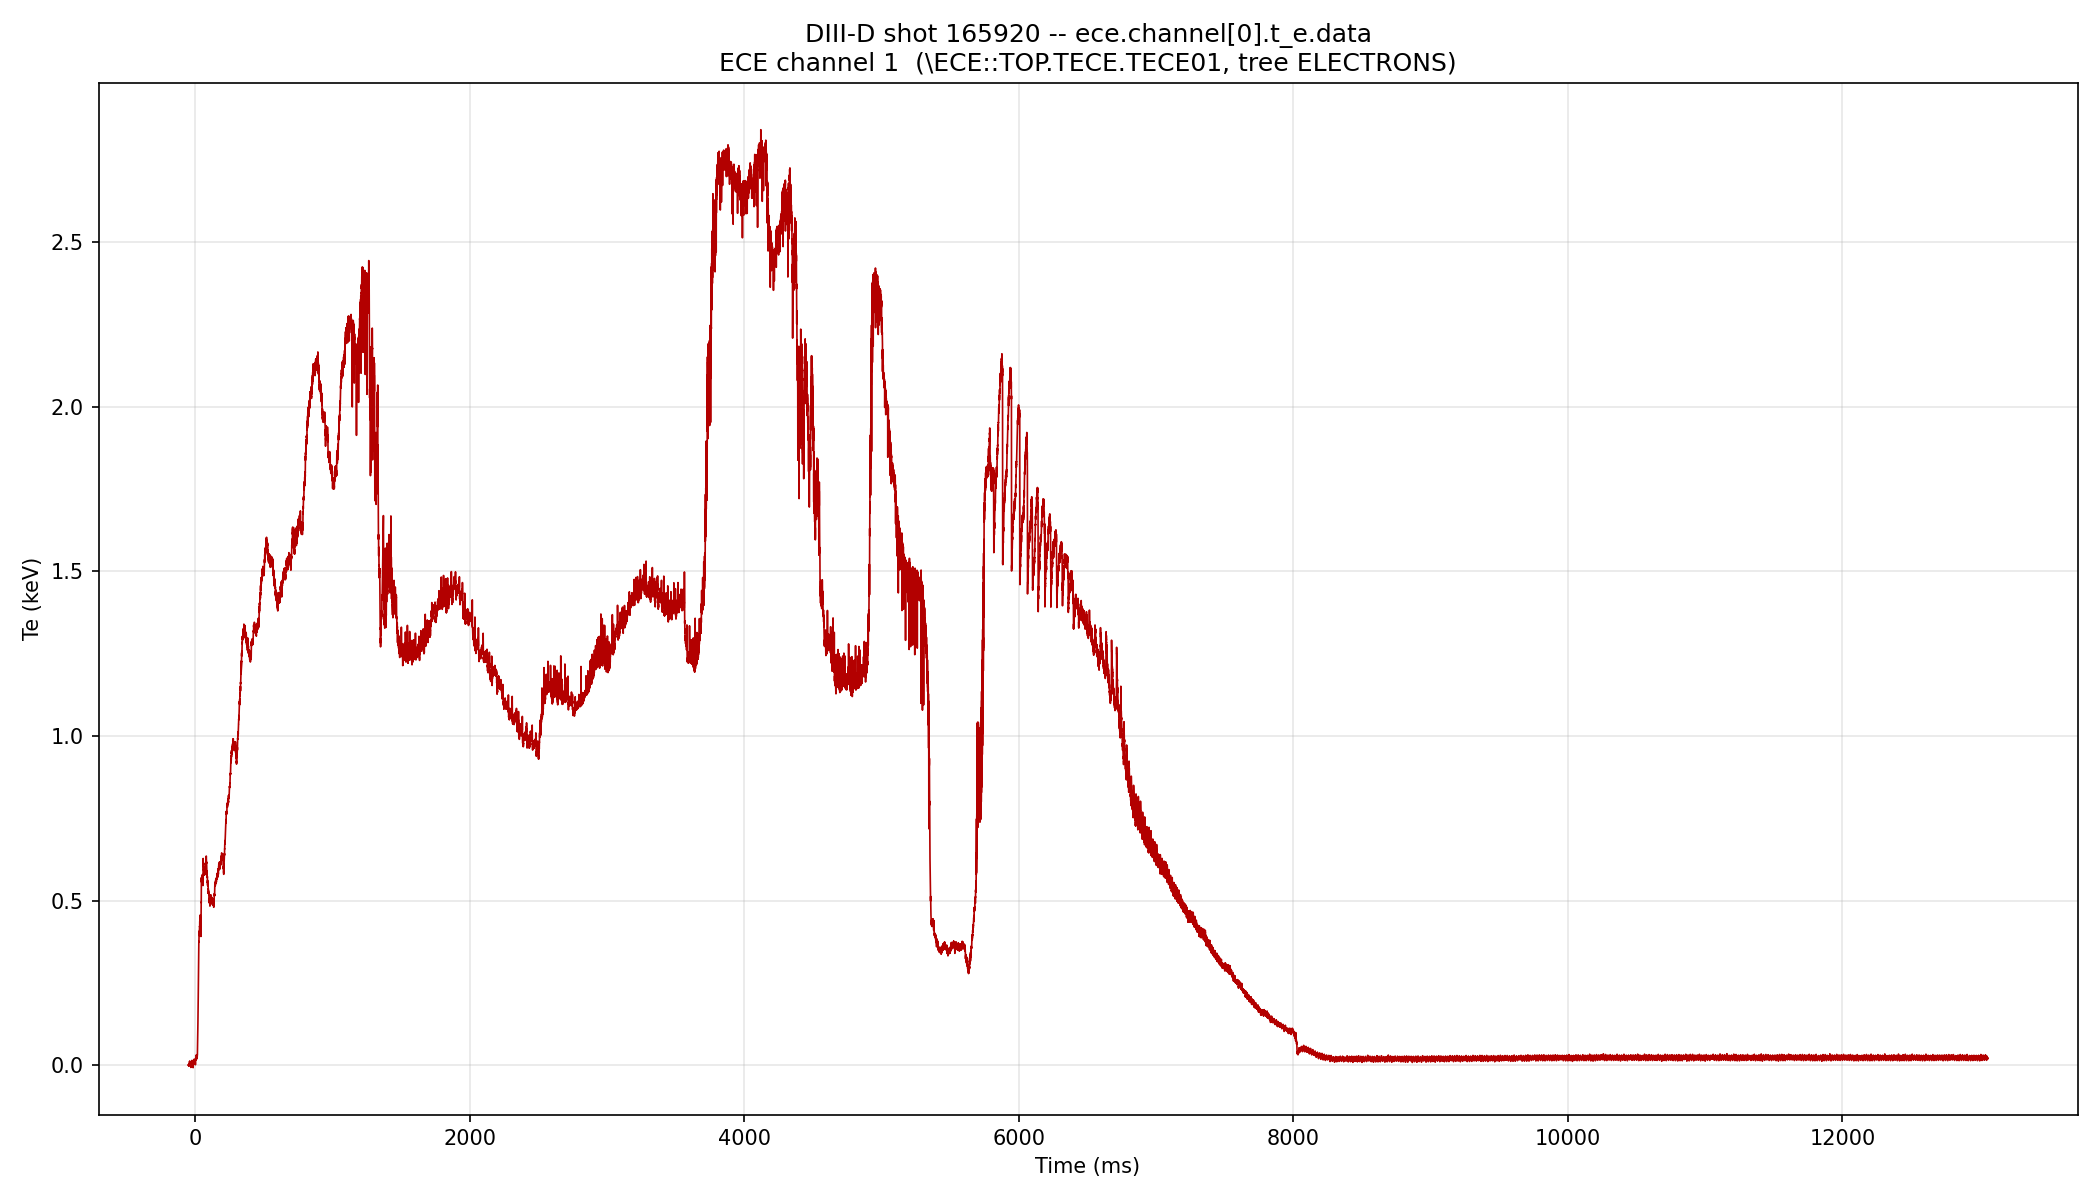

**Fetched** : `ece.channel[0].t_e.data` → `\ECE::TOP.TECE.TECE01` (tree **ELECTRONS** ) for shot 165920.

| metric | value |
|---|---|
| samples | 65,536 |
| range | -7.5 × 10⁻³ … 2.84 keV |
| time span | -50.0 … 13,057.0 ms |
| verification | **not verified** in the IMAS table (`verified: false`) — this is a `parameterized` template row, never confirmed by a real fetch |

**Two things worth noting:**

1. **This was a parameterized template.** The IMAS table lists the path as `\ECE::TOP.TECE.TECE{01-NUMCH}` with `parameterized: true` and `required_parameters: ['01-NUMCH']`. I substituted channel index `01` to get the concrete node `TECE01`. Per the skill's rule 8, that template string is not itself a fetchable signal — it needs the channel argument.

2. **The negative tail is expected.** The trace includes pre-discharge samples (t < 0) where the radiometer reads baseline noise, hence the near-zero/negative Te values. The flat-top temperature (~1–3 keV) is the physical plasma signal.

**COCOS** : none — ECE temperature carries no sign-convention transform.

This is a proof-of-concept for a single channel. The ECE radiometer has `NUMCH` channels total (`\ECE::TOP.CAL.NUMCH`); to fetch all of them you'd iterate `TECE01 … TECEN` by reading that count first.

In [15]:
%%ask
Fetch ece.channel.t_e.data for shot 165920. Just channel 1 to prove the concept.

*An **unverified** row — extracted but never fetched successfully (the `IONS` tree failed to open on all 8 shots). Expected to be flagged as unconfirmed, not presented as solid.*

In [16]:
%%ask
What is the IMAS name for charge_exchange._array_order?

I'll consult the skill for the lookup convention, including its Learnings file since this skill has one.

Now I'll look up the field directly.

`charge_exchange._array_order` maps cleanly to a single MDSplus node, but it is **unverified** — so the caution matters here.

**`charge_exchange._array_order`** → `\IONS::TOP.CER.CALIBRATION.ARRAY_ORDER` (tree **IONS** )

| field | value |
|---|---|
| `confidence` | `literal` (direct 1:1 node read) |
| `verified` | **`false`** |
| `shots tried` | [91388, 112031, 124415, 156199, 165920, 168442, 181681, 198189] |
| `last_error` | `TreeFOPENR` — the IONS tree could not be opened for reading |
| `fetch_with` | `MdsSignal` |
| `caution` | "This mapping was extracted but never fetched successfully; treat it as unconfirmed." |

**Two things to flag:**

1. **Unverified — do not treat the path as confirmed.** The extractor found this mapping in `imas_composer/ids/charge_exchange.py`, but the actual fetch failed on all 8 verification shots with a `TreeFOPENR` error (the IONS tree wouldn't open read-only). So while the path exists in the mapping code, it has never been confirmed to return data. Per the skill's rule 4, this row carries a `caution` field exactly because of this.

2. **Internal helper, not a public quantity.** The leading underscore marks this as an internal `imas_composer` helper, not a standard IMAS data-access field (cf. `equilibrium._cpasma_cocos`, `core_profiles._gtime`). Per rule 2, I won't infer its meaning from the name `_array_order` — the underscore-prefixed entries are internal plumbing whose behavior is defined by how the upstream composer code uses them, not by the field name. The path sits under `CER.CALIBRATION`, suggesting it is part of the charge-exchange-recombination (CER) diagnostic's calibration metadata, but that is an inference from the *path*, not a confirmed description, and the unverified status makes it doubly tentative.

If you want to confirm whether this node actually exists for a given shot, the next step would be a `MdsSignal` fetch against the IONS tree for that shot via the `d3d-shot-fetcher` skill — this lookup is names-only.

This is a PTDATA fetch (pointname `IP`), which per the skill rules requires `fdp run` since PTDATA doesn't work in-kernel. Let me consult the shot-fetcher skill first.

PTDATA `IP` fetch — requires `fdp run` since PTDATA won't work in-kernel. Writing the script.

Running the PTDATA fetch via `fdp run` (required for PTDATA per the skill).

Retrying without the timeout override.

Fetch succeeded on the first run — no errors, no edit-retry, so no Learnings entry needed.


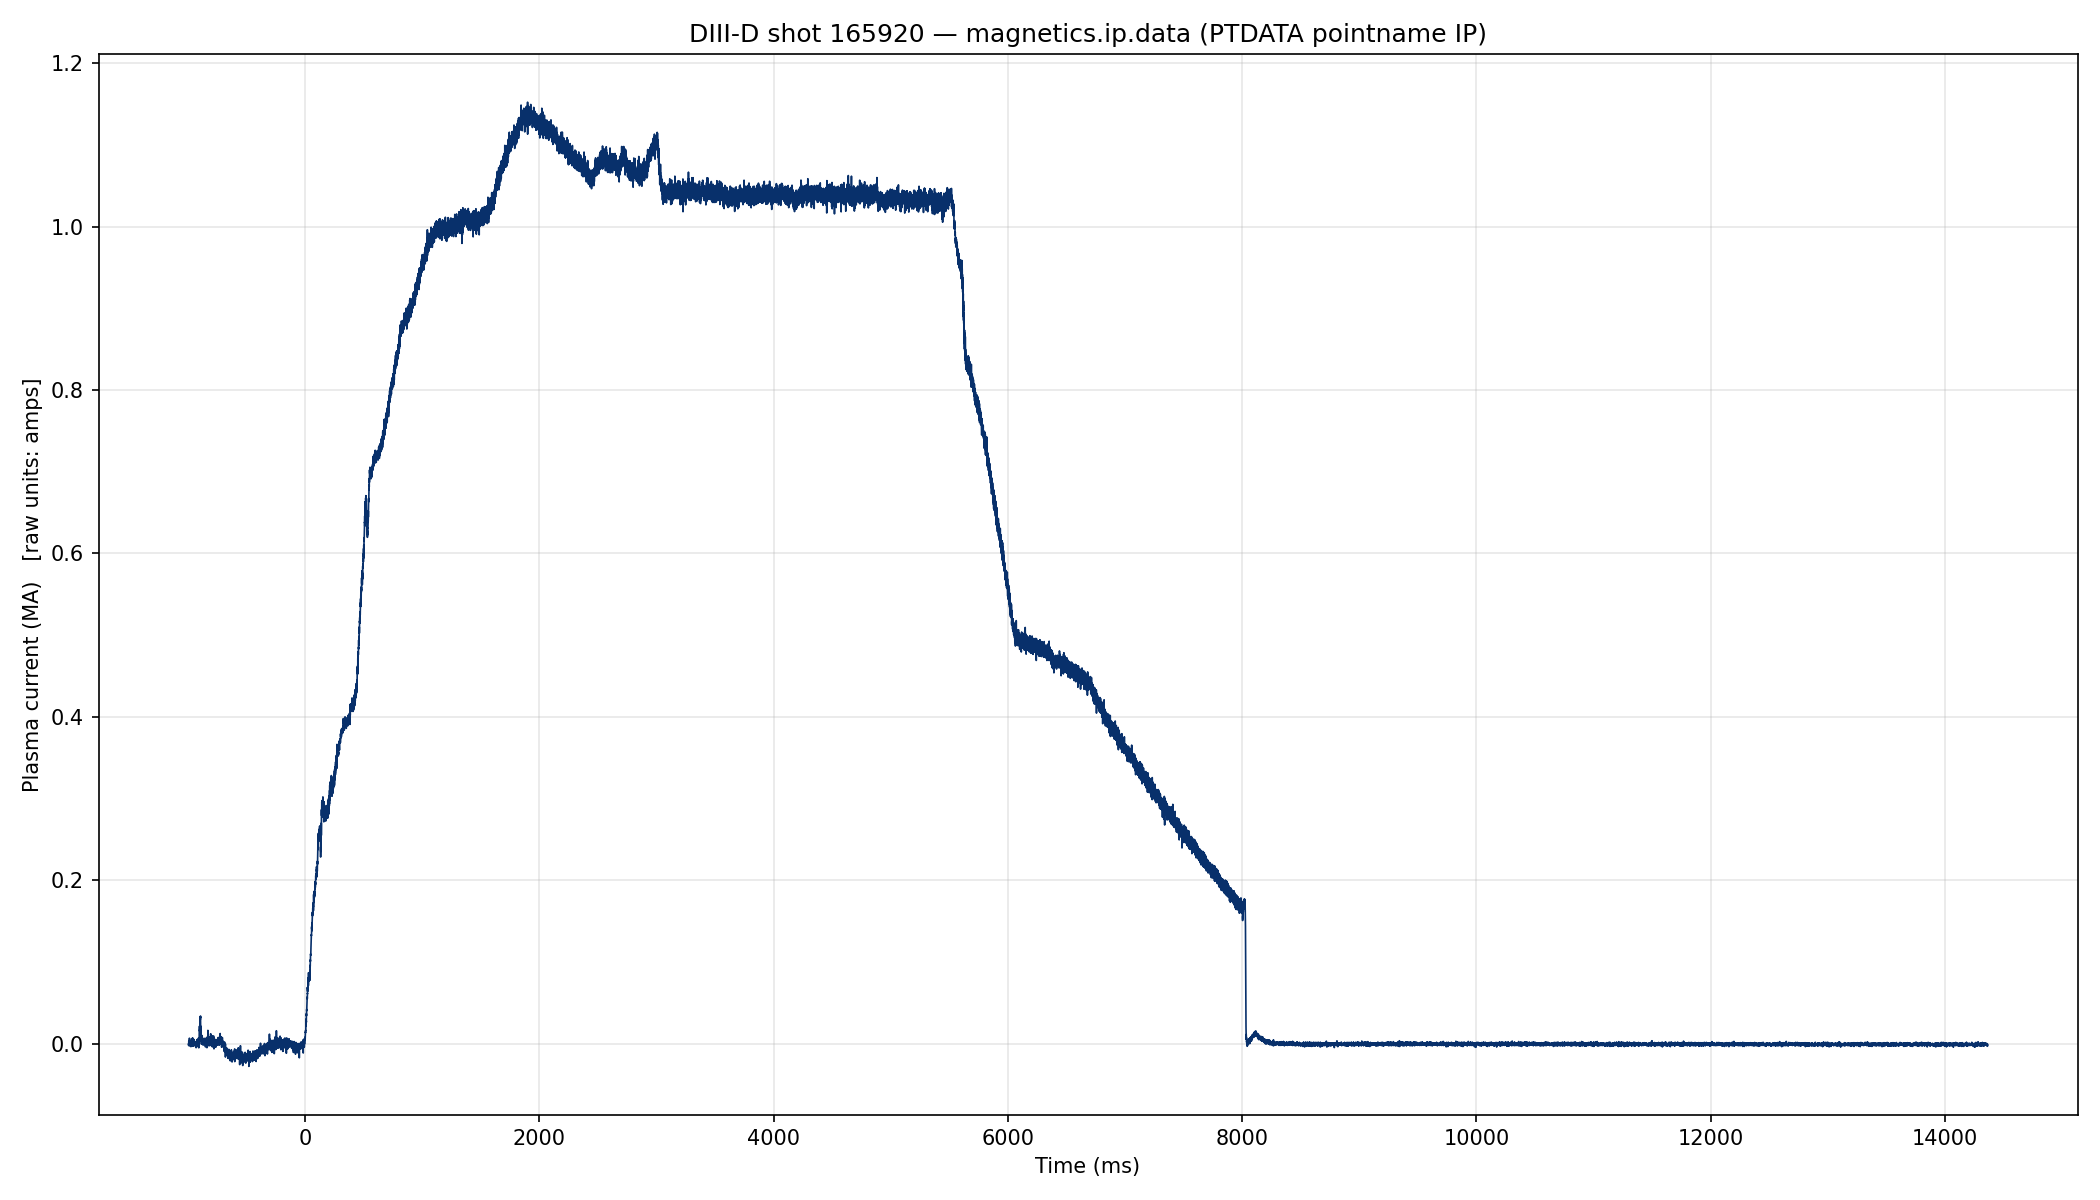

**Fetched** : `magnetics.ip.data` → PTDATA pointname `IP` for shot 165920.

| metric | value |
|---|---|
| samples | 30,720 |
| range | -2.80 × 10⁴ … 1.15 × 10⁶ A |
| time span | -996.0 … 14,363.5 ms |
| verification | `verified: true` on this shot |

**Two things worth noting:**

1. **Different source from the EFIT `\ipmhd` we plotted earlier.** This is a **raw digitizer trace** from the plasma control system / magnetics (PTDATA), not the equilibrium reconstruction. Expect the two to agree on the flat-top (~1.13–1.15 MA) but differ in detail — the PTDATA trace has far more samples (30,720 vs 315), a longer time span (it covers pre-shot and post-shot), and its peak (1.152 MA) is ~2% higher than EFIT's (1.130 MA). This is expected: same physical quantity, different diagnostic pipelines.

2. **COCOS caution (TOR).** This field carries a toroidal-quantity sign-convention transform. The trace above is plotted as the **raw DIII-D value** — serving it under the IMAS name without applying the TOR COCOS conversion can produce a sign-flipped number. The positive flat-top is consistent with the correct sign for a normal DIII-D discharge, but that should be confirmed against the IMAS convention rather than assumed.

In [17]:
%%ask
Fetch magnetics.ip.data for shot 165920

## 6. Composition — lookup feeding a fetch

The real workflow, and where defects hide: resolve an IMAS name, fetch
the DIII-D signal behind it, and keep the caveats attached to the
result. The second cell crosses eras, where sampling differs.

I'll compare the equilibrium-reconstruction plasma current against the raw magnetics PTDATA trace. Let me first read the skills to get the correct fetch approach for both signals.

I have the fetch patterns. The equilibrium field maps to `\EFIT01::TOP.MEASUREMENTS.CPASMA` (MDSplus), and magnetics maps to PTDATA pointname `IP`. Writing a script to fetch both and overlay them.

Running the comparison script via the fdp wrapper as required for PTDATA access.

Retrying without the timeout override.

Clean one-shot run — the comparison succeeded on the first attempt with no edit-retry cycle, so no Learnings entry is needed.


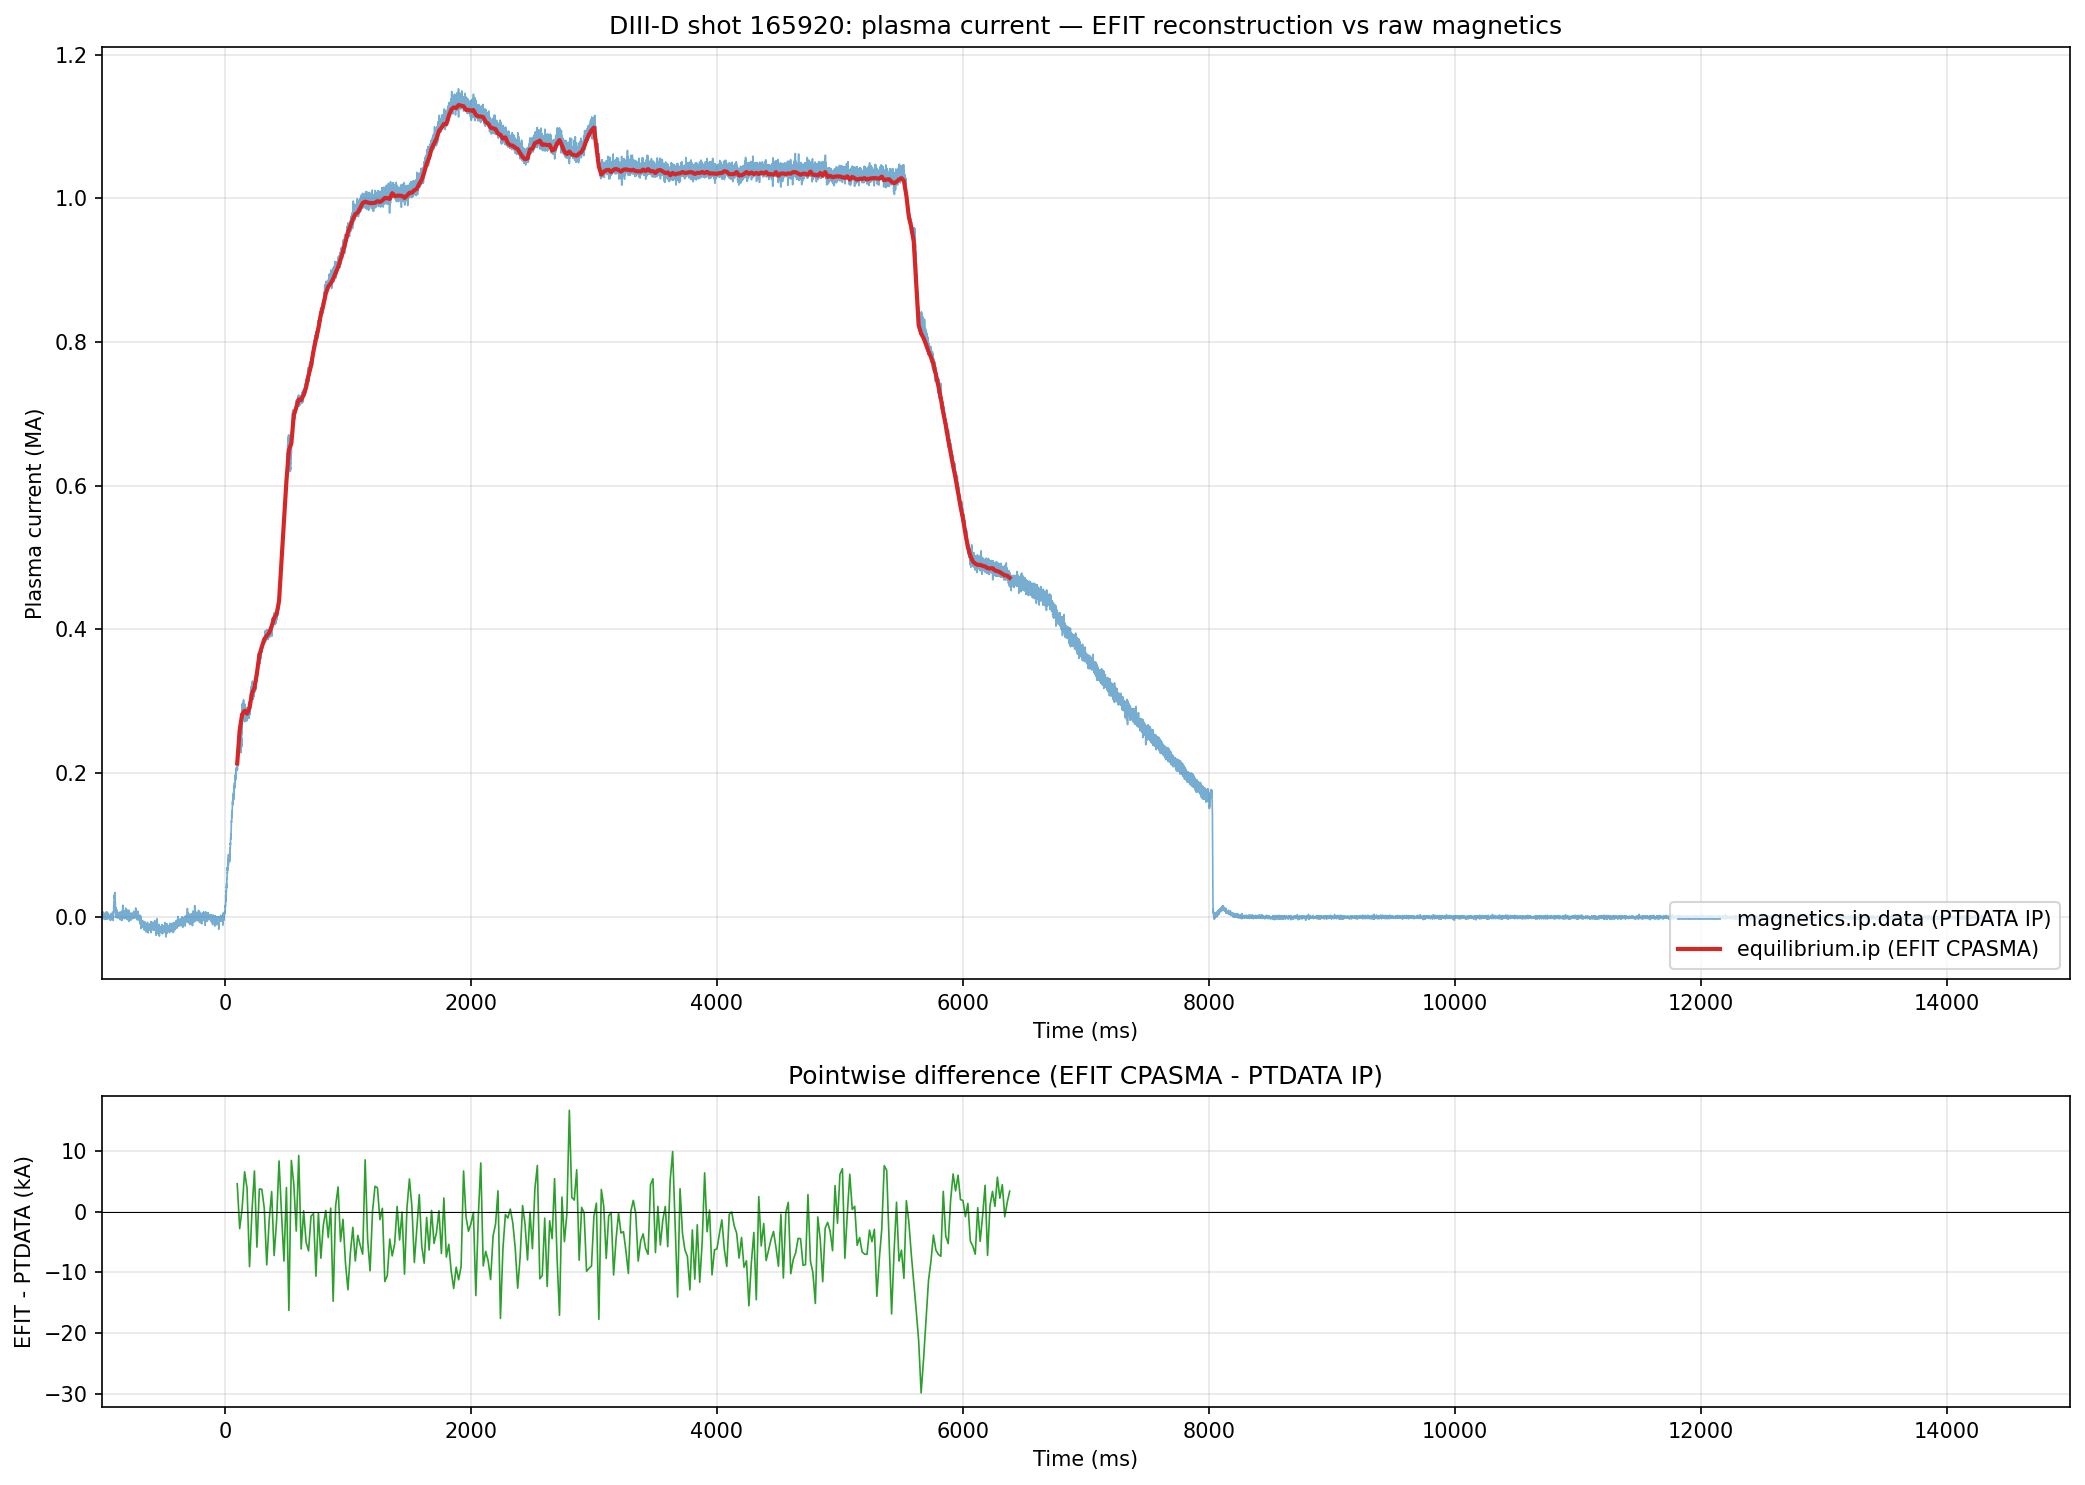

**Fetched both signals for shot 165920:**

| signal | IMAS field | source | samples | peak |
|---|---|---|---|---|
| EFIT CPASMA | `equilibrium.time_slice.global_quantities.ip` | `\EFIT01::TOP.MEASUREMENTS.CPASMA` (MDSplus) | 315 | 1.1299 MA |
| PTDATA IP | `magnetics.ip.data` | PTDATA pointname `IP` | 30,720 | 1.1524 MA |

**They agree closely.** The two are the same physical quantity (toroidal plasma current) measured through different diagnostic pipelines:

| metric | value |
|---|---|
| peak difference | -22.50 kA (-1.95%) |
| pointwise median diff | -3.50 kA |
| pointwise mean diff | -3.52 kA |
| pointwise std | 6.21 kA |
| max absolute diff | 29.90 kA |
| **median relative diff** | **-0.35%** |

**Key observations:**

1. **EFIT reads consistently ~2% lower at peak.** This is expected: `\EFIT01::TOP.MEASUREMENTS.CPASMA` is the EFIT *reconstruction's* plasma current — a Grad-Shafranov fit constrained by magnetics, not a direct measurement. The fit smooths and can slightly under-predict the true peak. The raw PTDATA `IP` digitizer trace captures the instantaneous value.

2. **Different time coverage and sampling.** EFIT has 315 samples over 100–6380 ms (one per EFIT time slice, ~20 ms spacing); PTDATA has 30,720 samples over -996–14363 ms (~0.5 ms spacing, including pre/post-shot). The difference panel (bottom of plot) resamples PTDATA onto EFIT's coarser grid for comparison.

3. **The largest discrepancies are during ramp-up/ramp-down** (edges of the flat-top), where the EFIT reconstruction lags the raw measurement — again expected for a fitted quantity.

4. **Both carry the TOR COCOS caution.** Both values are plotted as raw DIII-D values. The positive flat-top is consistent with the correct sign for this discharge, but serving either under the IMAS name requires confirming the sign convention.

**Bottom line:** For shot 165920, the equilibrium reconstruction and raw magnetics agree to within ~0.35% (median) on the plasma current. The ~2% peak offset is the expected diagnostic-pipeline difference, not an error in either signal.

In [18]:
%%ask
Compare equilibrium.time_slice.global_quantities.ip with magnetics.ip.data 
for shot 165920

This is a multi-shot fetch-and-compare task using the EFIT01 equilibrium tree. Let me consult the shot-fetcher skill and its learned lessons before writing the script.

Consulted the skill and its Learnings — key points: use `fdp run python`, raw strings for signal names, and (per the Learnings) the full path `\EFIT01::TOP.MEASUREMENTS:CPASMA` rather than the `\cpasma` tag, which resolves to a different node. Writing the fetch-and-compare script now.

Running the fetch-and-compare script via the fdp wrapper.

Retrying without the timeout override.

Clean one-shot run — no errors, no edit-retry, so no Learnings entry is needed.


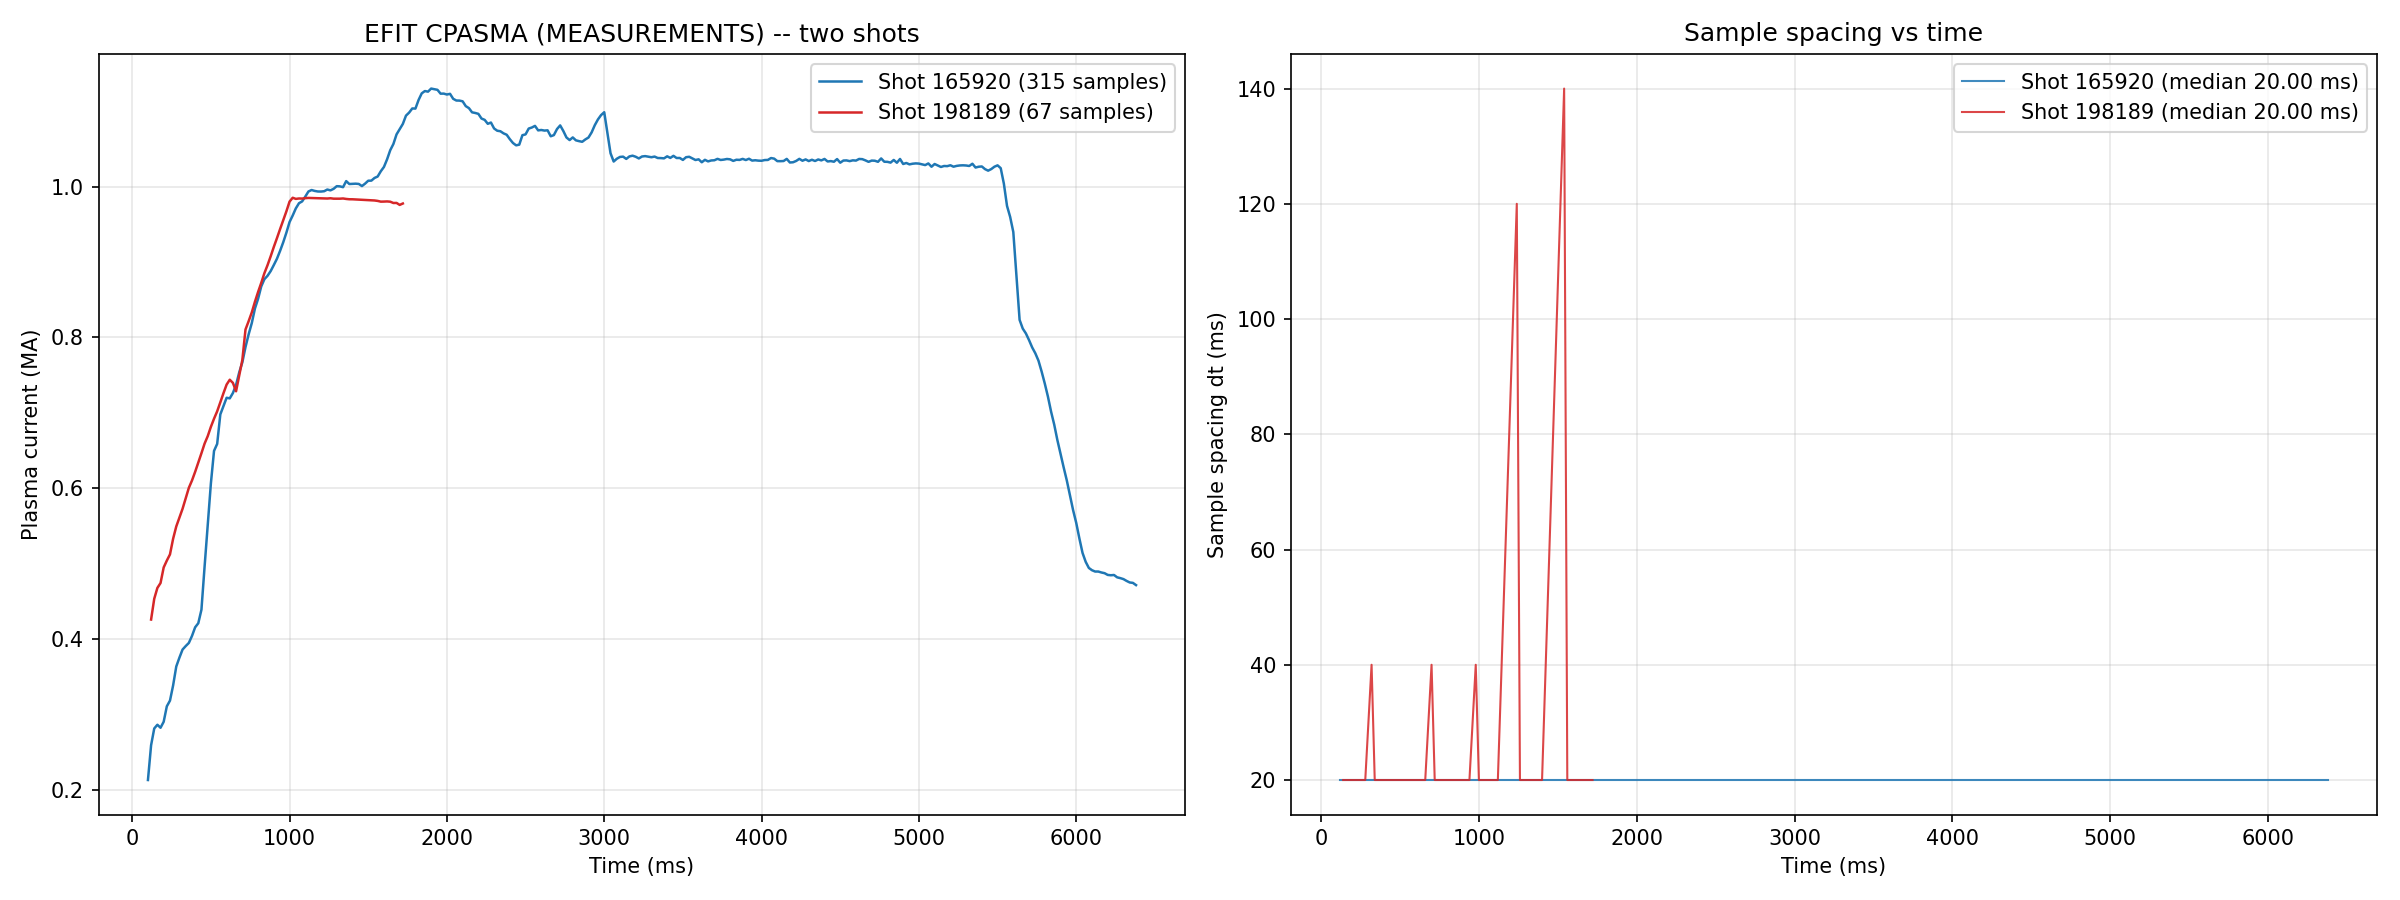

**Fetched** : `equilibrium.time_slice.global_quantities.ip` → `\EFIT01::TOP.MEASUREMENTS:CPASMA` (tree EFIT01) for shots 165920 and 198189.

## Sampling comparison

| metric | shot 165920 | shot 198189 |
|---|---|---|
| samples | 315 | 67 |
| time span | 100.0 – 6380.0 ms (6280 ms) | 120.0 – 1720.0 ms (1600 ms) |
| median dt | 20.00 ms | 20.00 ms |
| median rate | **50.0 Hz** | **50.0 Hz** |
| mean dt | 20.00 ms | 24.24 ms |
| mean rate | 50.0 Hz | 41.2 Hz |
| dt std | 0.00 ms | 19.23 ms |
| min / max dt | 20.0 / 20.0 ms | 20.0 / 140.0 ms |

## Key finding: same nominal rate, very different coverage

The two shots share the **same nominal sampling rate of 50 Hz** (one EFIT solution every 20 ms). But they differ sharply in almost every other respect:

1. **Sample count differs 5×.** Shot 165920 has 315 samples; 198189 has only 67. This is **not** a rate difference — it reflects the **plasma duration** . Shot 165920 ran a long discharge (EFIT covers 6.28 s); 198189's EFIT window is only 1.6 s, consistent with a much shorter-lived plasma.

2. **Shot 165920 is uniformly sampled.** Every sample spacing is exactly 20.0 ms (std = 0) — a clean, regular 50 Hz grid over the full discharge.

3. **Shot 198189 has irregular spacing.** The median dt is still 20 ms, but the std is 19.2 ms and the max gap is 140 ms — meaning EFIT solutions are missing for some time slices (gaps in the reconstruction), likely during ramp-up or near termination. The mean rate (41.2 Hz) is therefore lower than the median (50 Hz).

4. **Peak plasma current.** 165920 reaches 1.13 MA; 198189 reaches 0.99 MA — a smaller, shorter discharge.

**Bottom line:** the IMAS plasma-current quantity has a consistent **50 Hz EFIT reconstruction rate** across these two shots. The large difference in sample count (315 vs 67) is driven entirely by plasma duration and reconstruction coverage, not by a different sampling cadence.

**COCOS caution (TOR):** both traces are plotted as raw DIII-D values. The positive flat-top is consistent with the correct sign for normal DIII-D discharges, but serving under the IMAS name requires confirming the sign convention.

In [19]:
%%ask
Fetch the IMAS plasma current for shots 165920 and 198189 and compare 
sampling rates

## 7. Mistyped input

Everything above assumes the user types an IMAS path correctly. These two
do not. A typo and a genuinely-absent field both fail to match exactly, so
without near-miss scoring they would produce the same confident "not in
the table" answer.

*Deliberate typo (`quantites`). A mistyped path and a genuinely absent one both fail to match, so the skill scores near-misses: this should be recovered, not reported as absent.*

In [20]:
%%ask
What is the DIII-D signal for equilibrium.time_slice.global_quantites.ip?

That IMAS path has a **typo** : `global_quantites` should be `global_quantities` (the `i` before `t` is missing). A literal lookup against the misspelled path would return no match, so I'm answering for the correct spelling.

**`equilibrium.time_slice.global_quantities.ip`** → **`\EFIT01::TOP.MEASUREMENTS.CPASMA`** (tree **EFIT01** )

| field | value |
|---|---|
| `fetch_with` | `MdsSignal` (standard MDSplus — not PTDATA) |
| `confidence` | `derived` |
| `verified` | `true` on [91388, 156199, 165920, 168442, 181681, 198189] |
| `cocos_transform` | **TOR** — toroidal-quantity sign-convention caution |
| `composed` | **3 nodes** |

**Composed-field caution:** This is not a single raw node — it is built from three:

- `\EFIT01::TOP.MEASUREMENTS.CPASMA` (primary — the plasma current)
- `\EFIT01::TOP.RESULTS.GEQDSK.BCENTR` (toroidal field, for the convention transform)
- `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA` (reconstructed current, for convention detection)

The primary `MEASUREMENTS.CPASMA` is the value itself; `BCENTR` and `GEQDSK.CPASMA` are needed for the COCOS convention detection/conversion, not as additional current measurements.

This is the same field we fetched and compared earlier — it is the **EFIT reconstructed** plasma current, distinct from the raw PTDATA pointname `IP` (which backs `magnetics.ip.data`).

*Deliberate typo (missing `_1d`) that lands on a field with **incomplete provenance**. The path served is the EFIT *time base*, not a flux array, because the real source is unresolved upstream — the answer should flag that rather than explain why it makes sense.*

In [21]:
%%ask
Which DIII-D signal backs core_profiles.profiles.grid.psi?

That path is **missing the `1d` segment** — the IMAS standard path is `core_profiles.profiles_1d.grid.psi`, not `core_profiles.profiles.grid.psi`. Answering for the correct path.

This is the same `resolution_partial` field we discussed earlier, so I won't repeat the full detail — but here is the headline:

**`core_profiles.profiles_1d.grid.psi`** is **unresolved** — there is no usable DIII-D signal for it.

| flag | value | meaning |
|---|---|---|
| `mds_path` | `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` | the EFIT **time base** , not a flux array |
| `resolution_partial` | `True` | primary source could not be resolved |
| `unresolved_dependencies` | `core_profiles.profiles_1d._omfit_psi` | the **real** psi source, produced by OMFIT at runtime |
| `resolved_via` | `core_profiles._gtime` | the chain only reaches GTIME |
| `cocos_transform` | PSI | sign-convention caution (moot — no real value) |
| `verified_for_shot` | `true` on all standard shots | only confirms the GTIME node fetches, **not** that psi does |

The listed node `GTIME` is a **secondary dependency** (the time axis), not the poloidal-flux grid. The actual psi data comes from `_omfit_psi`, which is generated by the OMFIT/`imas_composer` pipeline at runtime — not a direct MDSplus node this table can resolve.

**Bottom line:** to get the 1-D poloidal-flux grid you must run the composer pipeline for the shot in question; it is **not** a `MdsSignal` fetch. Do not use GTIME as if it were psi.